# Task 1: House Price Prediction Using Linear Regression

Objective:
Build a Linear Regression model to predict house prices using:
- Living Area (GrLivArea)
- Number of Bedrooms (BedroomAbvGr)
- Number of Bathrooms (FullBath)

Dataset:
House Prices - Advanced Regression Techniques

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the Dataset

Read the training dataset and display the first few rows.

In [53]:
df = pd.read_csv('train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Select Relevant Features

The model will use:
- GrLivArea (Living Area)
- BedroomAbvGr (Bedrooms)
- FullBath (Bathrooms)

Target Variable:
- SalePrice

In [54]:
house_data = df[
    ['GrLivArea',
     'BedroomAbvGr',
     'FullBath',
     'SalePrice']
]

house_data.head()

,GrLivArea,BedroomAbvGr,FullBath,SalePrice
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


## Dataset Overview

Check dimensions, missing values and statistical summary.

In [55]:
print("Dataset Shape:", house_data.shape)

print("\nMissing Values:")
print(house_data.isnull().sum())

house_data.describe()

Dataset Shape: (1460, 4)

Missing Values:
GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64


,GrLivArea,BedroomAbvGr,FullBath,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,1.565068,180921.195890
std,525.480383,0.815778,0.550916,79442.502883
min,334.000000,0.000000,0.000000,34900.000000
25%,1129.500000,2.000000,1.000000,129975.000000
50%,1464.000000,3.000000,2.000000,163000.000000
75%,1776.750000,3.000000,2.000000,214000.000000
max,5642.000000,8.000000,3.000000,755000.000000


## Correlation Heatmap

Visualize the relationship between selected features and house prices.

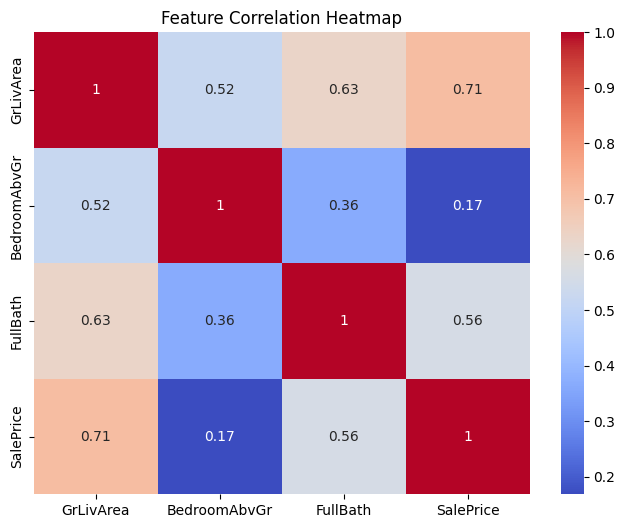

In [56]:
plt.figure(figsize=(8,6))

sns.heatmap(
    house_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

## Correlation Graph

This graph shows the relationship between Living Area and Sale Price.
The regression line represents the overall trend.

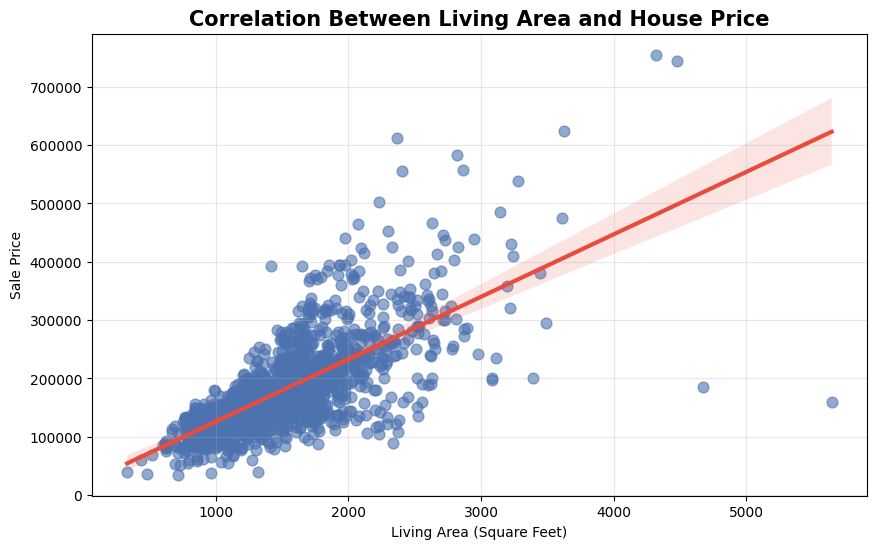

In [57]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='GrLivArea',
    y='SalePrice',
    data=house_data,

    scatter_kws={
        'color':'#4C72B0',
        'alpha':0.6,
        's':60
    },

    line_kws={
        'color':'#E74C3C',
        'linewidth':3
    }
)

plt.title(
    "Correlation Between Living Area and House Price",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Living Area (Square Feet)")
plt.ylabel("Sale Price")

plt.grid(True, alpha=0.3)

plt.show()

## Define Features and Target Variable

In [58]:
X = house_data[
    ['GrLivArea',
     'BedroomAbvGr',
     'FullBath']
]

y = house_data['SalePrice']

## Split Dataset

80% Training Data
20% Testing Data

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1168
Testing Samples: 292


## Train Linear Regression Model

In [60]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


## Generate Predictions

In [61]:
y_pred = model.predict(X_test)

## Evaluate Model Performance

Metrics Used:
- MAE
- MSE
- RMSE
- R² Score

In [62]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,4))

MAE : 35788.06
MSE : 2806426667.25
RMSE: 52975.72
R² Score: 0.6341


## Actual vs Predicted Values

In [63]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,154500,113410.672553
1,325000,305081.877759
2,115000,135904.785630
3,159000,205424.675641
4,315500,227502.683490
5,75500,121157.480796
6,311500,205577.980566
7,146000,183787.203783
8,84500,121157.480796
9,135500,147219.222332


## Actual vs Predicted House Prices

The closer the points are to the red dashed line,
the better the model predictions.

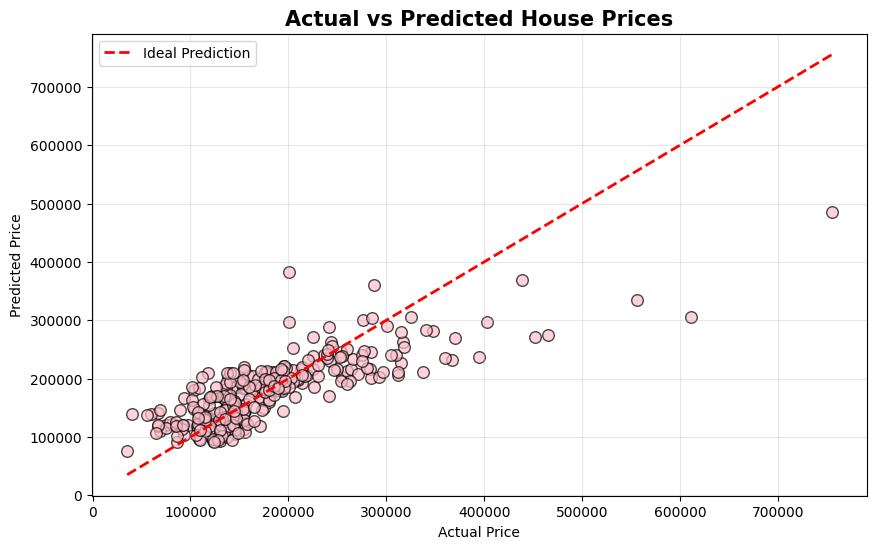

In [64]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    color='pink',
    alpha=0.7,
    edgecolors='black',
    s=70
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.title(
    "Actual vs Predicted House Prices",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

## Feature Importance

Linear Regression coefficients indicate how much each feature
contributes to the final prediction.

In [65]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,GrLivArea,104.026307
1,BedroomAbvGr,-26655.165357
2,FullBath,30014.324109


## Feature Importance Visualization

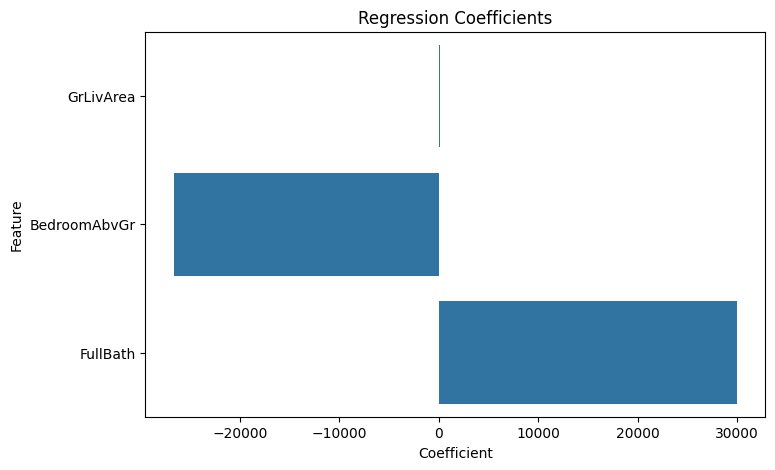

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients
)

plt.title("Regression Coefficients")

plt.show()

## Predict Price for a New House

In [67]:
new_house = pd.DataFrame({
    'GrLivArea':[2000],
    'BedroomAbvGr':[3],
    'FullBath':[2]
})

predicted_price = model.predict(new_house)

print("Predicted House Price: $", round(predicted_price[0],2))

Predicted House Price: $ 240377.51


# Conclusion

A Linear Regression model was developed to predict house prices
using living area, number of bedrooms and number of bathrooms.

The model was evaluated using MAE, MSE, RMSE and R² Score.
Correlation analysis showed that living area has the strongest
relationship with house prices.

The Actual vs Predicted graph indicates that the model is able
to capture the overall pricing trend and provide reasonable
house price predictions.